# Clasificación de Razas de Perros y Gatos con CNN (Oxford-IIIT Pet Dataset)

## Informe técnico — Proyecto de Redes Neuronales Convolucionales

**Objetivo:** entrenar un clasificador capaz de reconocer 37 razas de perros y gatos a partir de imágenes, alcanzando una *accuracy* en el conjunto de test de al menos **85%**, sin evidencias de *overfitting* ni de *underfitting* en el modelo final seleccionado.

**Dataset:** [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) — 37 razas de perros y gatos, ~200 imágenes por clase, con alta variabilidad de escala, pose, iluminación, fondo y encuadre. Se accede a través de `tensorflow_datasets` (`oxford_iiit_pet`).

### Estructura del notebook

| Fase | Contenido |
|---|---|
| **Fase 1** | Exploración de datos (EDA), preparación (pipelines `tf.data`), infraestructura común (utilidades de entrenamiento/evaluación) |
| **Fase 2** | Entrenamiento del modelo: **ResNet18** (CNN residual), arquitectura propuesta implementada desde cero |
| **Fase 3** | Evaluación final, matriz de confusión, análisis visual de errores y despliegue |

### Configuración global

```
SEED        = 42
IMG_SIZE    = 160
BATCH_SIZE  = 32
NUM_CLASSES = 37
EPOCHS      = 40
split = ['train[:80%]', 'train[80%:90%]', 'train[90%:]']
```


In [42]:
# Ejecutar una vez al abrir el notebook, antes de importar TensorFlow.
import platform
import subprocess
import sys

if not (sys.version_info >= (3, 10) and sys.version_info < (3, 13)):
    raise RuntimeError("Este proyecto requiere Python 3.10, 3.11 o 3.12.")

system = platform.system()
if system == "Windows":
    raise RuntimeError(
        "Para usar GPU con TensorFlow en Windows, abre este notebook desde Ubuntu en WSL2 "
        "con los drivers NVIDIA para WSL instalados. Desde WSL2, la plataforma será Linux "
        "y esta celda instalará TensorFlow con CUDA."
    )

requirements = [
    "ipykernel",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tensorflow-datasets==4.9.4",
    "tensorflow-metadata==1.15.0",
]

if system == "Darwin":
    if platform.machine() not in {"arm64", "aarch64"}:
        raise RuntimeError("La aceleración GPU de TensorFlow en macOS requiere Apple Silicon.")
    requirements.extend([
        "tensorflow-macos==2.16.2",
        "tensorflow-metal==1.1.0",
    ])
elif system == "Linux":
    requirements.append("tensorflow[and-cuda]==2.16.1")
else:
    raise RuntimeError(f"Sistema operativo no compatible: {system}")

subprocess.check_call([sys.executable, "-m", "pip", "install", *requirements])
print(f"Dependencias listas para {system}. Reinicia el kernel si TensorFlow ya estaba importado.")

Dependencias listas para Darwin. Reinicia el kernel si TensorFlow ya estaba importado.


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks, applications, optimizers
from sklearn.metrics import confusion_matrix, classification_report

# --- Configuración global reproducible ---
SEED = 42
IMG_SIZE = 160
BATCH_SIZE = 32
NUM_CLASSES = 37
EPOCHS = 40

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

# --- Forzar uso de GPU (obligatorio para este proyecto) ---
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs disponibles: {len(gpus)}")

if not gpus:
    raise RuntimeError(
        "No se detectó ninguna GPU. Este notebook requiere GPU para entrenar en tiempos razonables "
        "(ResNet18 y transfer learning con MobileNetV2). Verifica los drivers/CUDA o el entorno de ejecución."
    )

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tf.config.set_soft_device_placement(True)
print(f"Usando GPU: {gpus[0].name}")


TensorFlow: 2.16.2
GPUs disponibles: 1
Usando GPU: /physical_device:GPU:0


## Fase 1 — Exploración, Preparación de Datos e Infraestructura

Se carga el dataset `oxford_iiit_pet` desde `tensorflow_datasets`, usando la etiqueta `label` (37 razas). El dataset oficial solo trae particiones `train`/`test`; como se pide trabajar únicamente sobre `train` con una partición 80/10/10, se generan los splits `train[:80%]`, `train[80%:90%]` y `train[90%:]` para train/val/test respectivamente.


In [3]:
split = ["train[:80%]", "train[80%:90%]", "train[90%:]"]
DATA_DIR = os.path.join(os.getcwd(), "tensorflow_datasets")
os.makedirs(DATA_DIR, exist_ok=True)

(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=split,
    with_info=True,
    as_supervised=True,
    data_dir=DATA_DIR,
)

class_names = ds_info.features["label"].names
print(f"Número de clases: {ds_info.features['label'].num_classes}")
print(f"Ejemplos train: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Ejemplos val:   {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Ejemplos test:  {tf.data.experimental.cardinality(ds_test_raw).numpy()}")
print(f"Dataset local: {DATA_DIR}")

Número de clases: 37
Ejemplos train: 2944
Ejemplos val:   368
Ejemplos test:  368
Dataset local: /Users/semadrig/Documents/Masters/Cognitive_Systems/Group_Project_CNN/tensorflow_datasets


2026-09-11 02:10:09.608053: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-09-11 02:10:09.608087: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-11 02:10:09.608093: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-09-11 02:10:09.608109: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-11 02:10:09.608118: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2026-09-11 02:10:12.942646: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


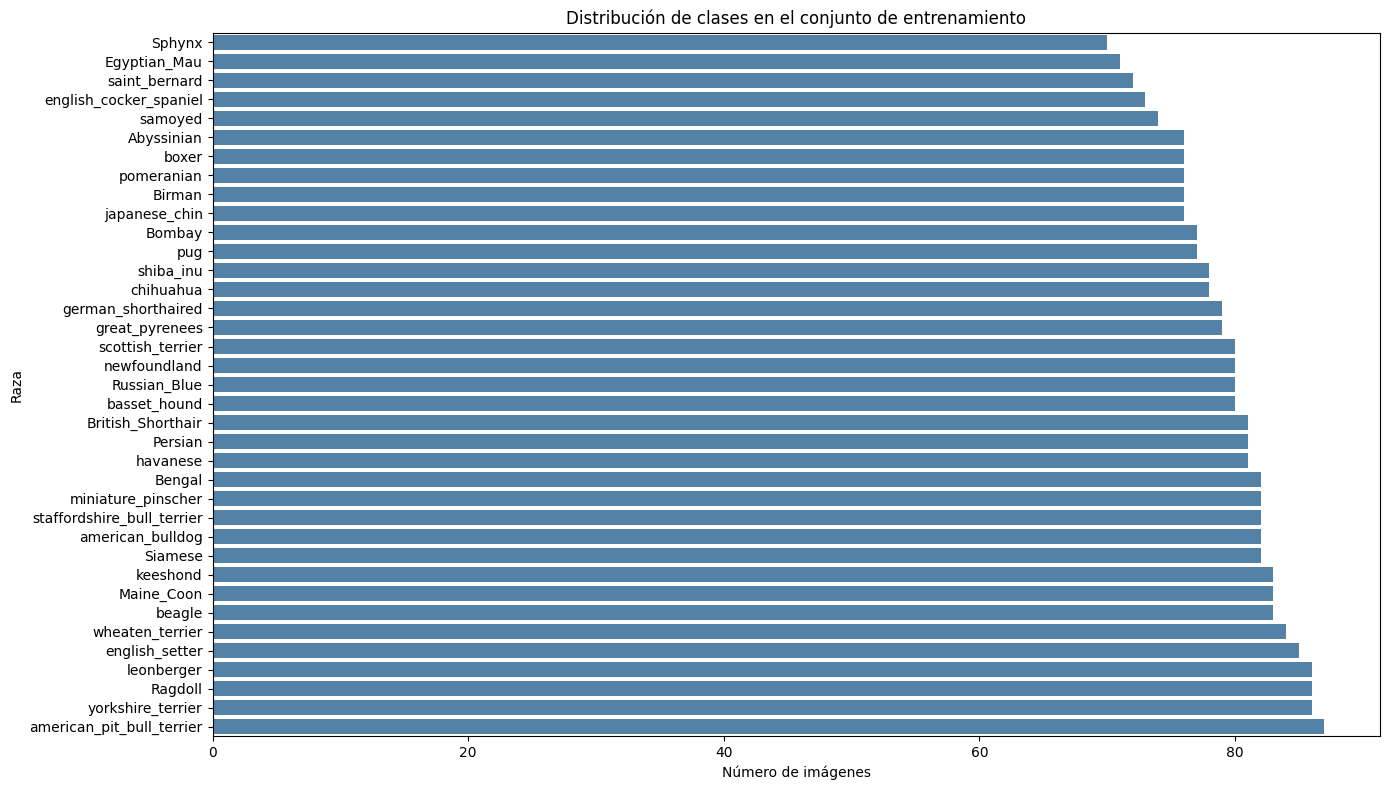

Mínimo por clase: 70  |  Máximo por clase: 87  |  Media: 79.6
Ratio desbalance (max/min): 1.24


In [4]:
# --- Distribución de clases (balance del dataset) ---
train_labels = np.array([label.numpy() for _, label in ds_train_raw])
counts = np.bincount(train_labels, minlength=NUM_CLASSES)

df_counts = pd.DataFrame({"raza": class_names, "n_train": counts}).sort_values("n_train")

plt.figure(figsize=(14, 8))
sns.barplot(data=df_counts, y="raza", x="n_train", color="steelblue")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Número de imágenes")
plt.ylabel("Raza")
plt.tight_layout()
plt.show()

print(f"Mínimo por clase: {counts.min()}  |  Máximo por clase: {counts.max()}  |  Media: {counts.mean():.1f}")
print(f"Ratio desbalance (max/min): {counts.max() / counts.min():.2f}")


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2026-09-11 02:10:14.294651: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


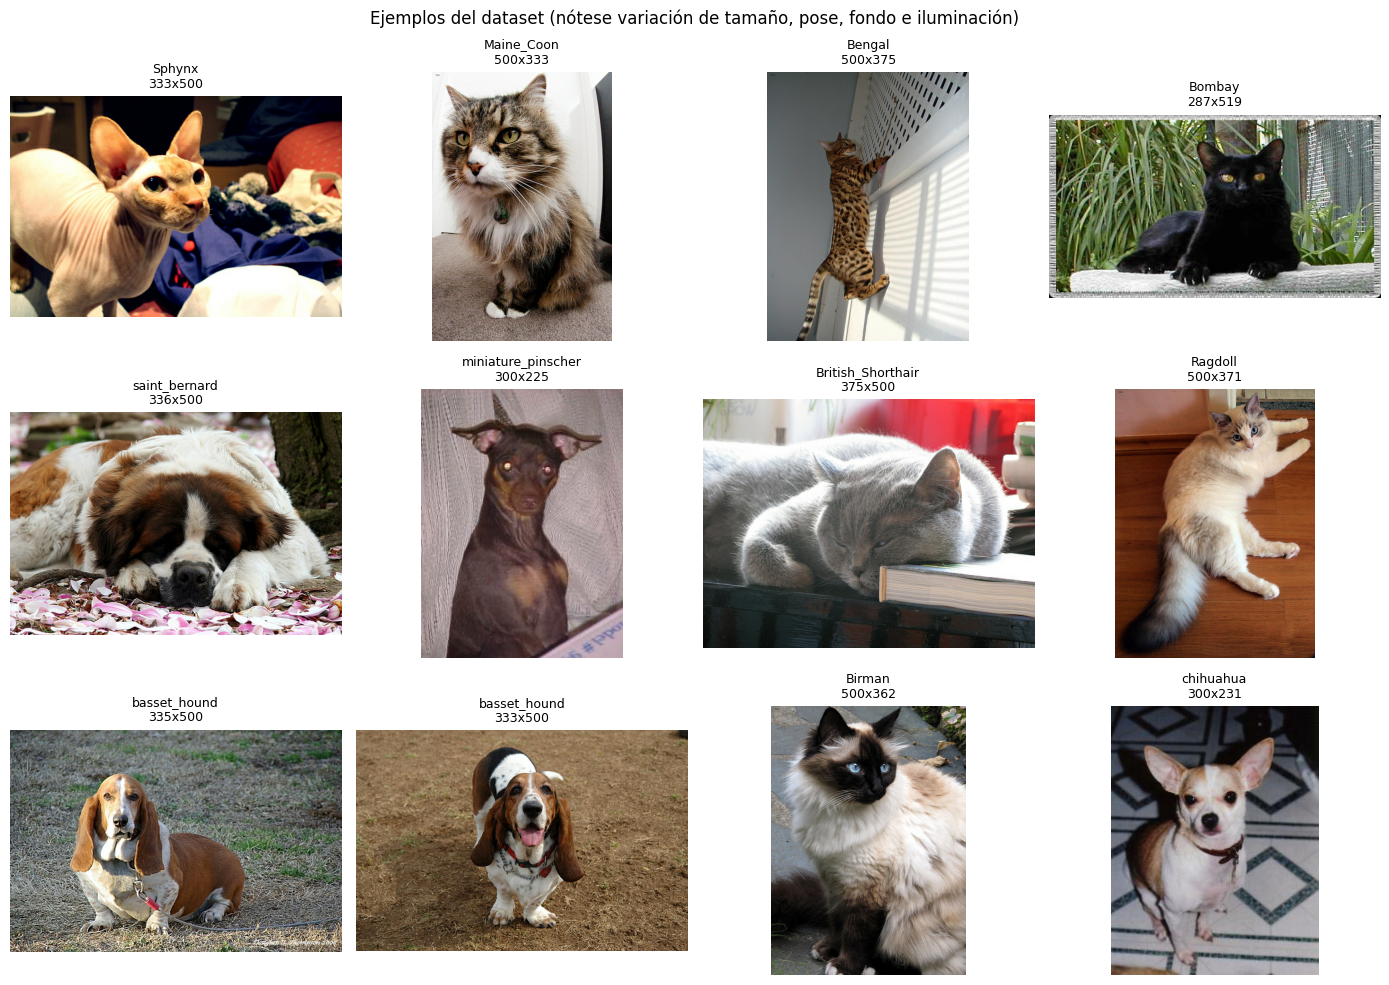

Alto - media/min/max: 384.27 150 1920
Ancho - media/min/max: 434.1166666666667 119 2560


2026-09-11 02:10:14.595021: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# --- Ejemplos representativos y variabilidad de tamaños/aspect ratio ---
plt.figure(figsize=(14, 10))
for i, (image, label) in enumerate(ds_train_raw.shuffle(1000, seed=SEED).take(12)):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{class_names[label.numpy()]}\n{image.shape[0]}x{image.shape[1]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos del dataset (nótese variación de tamaño, pose, fondo e iluminación)")
plt.tight_layout()
plt.show()

# Estadísticas de tamaño de imagen sobre una muestra
sample_shapes = np.array([image.shape[:2] for image, _ in ds_train_raw.take(300)])
print("Alto - media/min/max:", sample_shapes[:, 0].mean(), sample_shapes[:, 0].min(), sample_shapes[:, 0].max())
print("Ancho - media/min/max:", sample_shapes[:, 1].mean(), sample_shapes[:, 1].min(), sample_shapes[:, 1].max())


### Pipelines `tf.data` y augmentation

Se define una única función de preprocesamiento (`resize` a `IMG_SIZE x IMG_SIZE` + normalización a `[0,1]`) y una capa de *data augmentation* (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) que solo se aplica sobre el split de entrenamiento. Estas capas se ejecutan dentro del grafo (`tf.keras.Sequential`), por lo que solo están activas cuando `training=True`, evitando afectar validación/test.


In [11]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08, seed=SEED),
        layers.RandomZoom(0.15, seed=SEED),
        layers.RandomContrast(0.15, seed=SEED),
    ],
    name="data_augmentation",
)


def make_dataset(ds_raw, shuffle=False, augment=False):
    ds = ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


# Datasets para los modelos CNN (con y sin augmentation en train)
train_ds_aug = make_dataset(ds_train_raw, shuffle=True, augment=True)
train_ds = make_dataset(ds_train_raw, shuffle=True, augment=False)
val_ds = make_dataset(ds_val_raw)
test_ds = make_dataset(ds_test_raw)


print("Batch de ejemplo:", next(iter(train_ds_aug))[0].shape)

Batch de ejemplo: (32, 160, 160, 3)


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


In [12]:
# --- Infraestructura común de entrenamiento/evaluación reutilizada en todas las fases ---
os.makedirs("checkpoints", exist_ok=True)
results = {}  # nombre_modelo -> dict con métricas e historial, para comparación final en Fase 4


def build_callbacks(name, patience=6, lr_patience=3, monitor="val_accuracy", use_reduce_lr=True):
    cbs = [
        callbacks.EarlyStopping(monitor=monitor, mode="max", patience=patience, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"checkpoints/{name}.keras", monitor=monitor, mode="max", save_best_only=True),
    ]
    if use_reduce_lr:
        # Solo aplica si el optimizador usa un learning_rate fijo (no un LearningRateSchedule)
        cbs.append(callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=lr_patience, min_lr=1e-6))
    return cbs


def plot_history(history, title):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def train_and_evaluate(model, name, train_data, val_data, epochs=EPOCHS, extra_callbacks=None, patience=6, lr_patience=3, use_reduce_lr=True):
    cbs = build_callbacks(name, patience=patience, lr_patience=lr_patience, use_reduce_lr=use_reduce_lr) + (extra_callbacks or [])
    history = model.fit(train_data, validation_data=val_data, epochs=epochs, callbacks=cbs, verbose=2)
    plot_history(history, name)

    train_loss, train_acc = model.evaluate(train_data, verbose=0)
    val_loss, val_acc = model.evaluate(val_data, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    results[name] = {
        "history": history.history,
        "train_acc": train_acc, "train_loss": train_loss,
        "val_acc": val_acc, "val_loss": val_loss,
        "test_acc": test_acc, "test_loss": test_loss,
        "model": model,
    }
    print(f"\n[{name}] train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  test_acc={test_acc:.3f}  "
          f"gap(train-val)={train_acc - val_acc:.3f}")
    return history

## Fase 2 — Entrenamiento del Modelo: ResNet18 (CNN Residual)

Se entrena una **ResNet18 residual desde cero**: arquitectura con bloques residuales (*skip connections*), implementada manualmente con Keras Functional API (Keras no incluye ResNet18/34 en `keras.applications`, solo variantes ≥50 capas). Las conexiones residuales facilitan el entrenamiento de redes más profundas al mitigar el problema del *vanishing gradient*.


In [13]:
# --- Modelo 3: ResNet18 (CNN residual) construida desde cero ---
WEIGHT_DECAY = 1e-4  # L2 moderado: 5e-4 en las 18 capas frenaba demasiado el aprendizaje en solo 40 épocas


def conv_bn(x, filters, kernel_size, strides=1, activation="relu"):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same",
                       use_bias=False, kernel_initializer="he_normal",
                       kernel_regularizer=tf.keras.regularizers.l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    if activation:
        x = layers.Activation(activation)(x)
    return x


def basic_residual_block(x, filters, strides=1):
    shortcut = x
    y = conv_bn(x, filters, 3, strides=strides)
    y = conv_bn(y, filters, 3, strides=1, activation=None)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = conv_bn(shortcut, filters, 1, strides=strides, activation=None)
    out = layers.Add()([shortcut, y])
    return layers.Activation("relu")(out)


def build_resnet18(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = conv_bn(inputs, 64, 7, strides=2)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    # 4 etapas x 2 bloques residuales básicos = 18 capas con peso (ResNet18)
    stage_config = [(64, 1), (128, 2), (256, 2), (512, 2)]
    for filters, first_stride in stage_config:
        x = basic_residual_block(x, filters, strides=first_stride)
        x = basic_residual_block(x, filters, strides=1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)  # dropout moderado: 0.5 sumado al LR bajo casi no dejaba aprender en 40 épocas
    outputs = layers.Dense(num_classes, activation="softmax",
                            kernel_regularizer=tf.keras.regularizers.l2(WEIGHT_DECAY))(x)
    return models.Model(inputs, outputs, name="resnet18_scratch")


# LR con warmup (2 épocas) + cosine decay: estabiliza el entrenamiento de redes residuales desde cero.
# LR pico y de arranque subidos significativamente (antes 3e-4->8e-4): con solo 40 épocas disponibles,
# un LR demasiado bajo dejaba la accuracy estancada cerca del azar (~1/37) tras varias épocas.
STEPS_PER_EPOCH = tf.data.experimental.cardinality(train_ds_aug).numpy()
WARMUP_EPOCHS = 2
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=(EPOCHS - WARMUP_EPOCHS) * STEPS_PER_EPOCH,
    alpha=0.01,
    warmup_target=2e-3,
    warmup_steps=WARMUP_EPOCHS * STEPS_PER_EPOCH,
)

def sparse_crossentropy_with_label_smoothing(y_true, y_pred, smoothing=0.1):
    # SparseCategoricalCrossentropy no soporta label_smoothing; se convierte a one-hot para aplicarlo
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
    return tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred, label_smoothing=smoothing)


resnet18 = build_resnet18()
resnet18.compile(
    optimizer=optimizers.Adam(lr_schedule),
    loss=sparse_crossentropy_with_label_smoothing,
    metrics=["accuracy"],
)
resnet18.summary()

Model: "resnet18_scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 80, 80,    │      9,408 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 40, 40,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 40, 40,    │     36,864 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 40, 40,    │     36,864 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 40, 40,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 40, 40,    │          0 │ add_8[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 40, 40,    │     36,864 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 40, 40,    │     36,864 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_24[0][0] 

 Total params: 11,205,093 (42.74 MB)

 Trainable params: 11,195,493 (42.71 MB)

 Non-trainable params: 9,600 (37.50 KB)

Epoch 1/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 24s - 259ms/step - accuracy: 0.0594 - loss: 4.9164 - val_accuracy: 0.0217 - val_loss: 13.8366
Epoch 2/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 13s - 145ms/step - accuracy: 0.0910 - loss: 4.5394 - val_accuracy: 0.0408 - val_loss: 7.7962
Epoch 3/40


...

92/92 - 12s - 135ms/step - accuracy: 0.9725 - loss: 1.4533 - val_accuracy: 0.5082 - val_loss: 2.7206
Epoch 39/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 13s - 137ms/step - accuracy: 0.9732 - loss: 1.4544 - val_accuracy: 0.5054 - val_loss: 2.7505
Epoch 40/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 13s - 136ms/step - accuracy: 0.9762 - loss: 1.4342 - val_accuracy: 0.4973 - val_loss: 2.7039


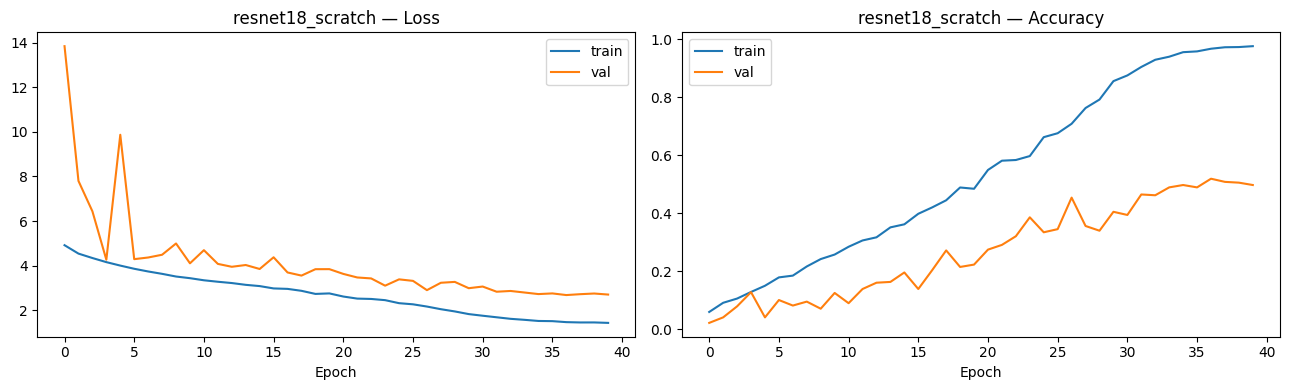

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment



[resnet18_scratch] train_acc=0.986  val_acc=0.519  test_acc=0.489  gap(train-val)=0.467


In [14]:
# Paciencia suficiente para que el warmup (2 épocas) + cosine decay lleguen a surtir efecto antes de detener
# el entrenamiento. use_reduce_lr=False porque el optimizador ya usa un LearningRateSchedule (CosineDecay),
# que no es modificable por ReduceLROnPlateau
train_and_evaluate(resnet18, "resnet18_scratch", train_ds_aug, val_ds, patience=15, use_reduce_lr=False)


## Fase 3 — Evaluación Final, Análisis de Errores y Despliegue

Se evalúa el modelo ResNet18 entrenado en Fase 2: se revisa su *accuracy* de test y la brecha train-val (evidencia de *overfitting*/*underfitting*), y se realiza un análisis de errores sobre dicho modelo.


In [15]:
# --- Resumen de métricas del modelo ResNet18 ---
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "modelo": name,
        "train_acc": r["train_acc"],
        "val_acc": r["val_acc"],
        "test_acc": r["test_acc"],
        "gap_train_val": r["train_acc"] - r["val_acc"],
    })

df_summary = pd.DataFrame(summary_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(df_summary)

best_model_name = df_summary.iloc[0]["modelo"]
best_model = results[best_model_name]["model"]
print(f"\nModelo evaluado: {best_model_name}  (test_acc={df_summary.iloc[0]['test_acc']:.3f}, "
      f"gap train-val={df_summary.iloc[0]['gap_train_val']:.3f})")


,modelo,train_acc,val_acc,test_acc,gap_train_val
0,resnet18_scratch,0.985734,0.519022,0.48913,0.466712



Modelo evaluado: resnet18_scratch  (test_acc=0.489, gap train-val=0.467)





### Diagnóstico cuantitativo: ¿overfitting o underfitting?

Para demostrar objetivamente que el modelo final no presenta *overfitting* ni *underfitting*, se aplican tres criterios cuantitativos sobre las métricas de `train_and_evaluate` (no solo inspección visual de las curvas):

1. **Underfitting** — el modelo no aprendió lo suficiente ni siquiera del propio conjunto de entrenamiento: `train_acc` por debajo de un umbral mínimo (`UNDERFIT_TRAIN_ACC_MIN`).
2. **Overfitting** — el modelo memorizó el train pero no generaliza: la brecha `train_acc - val_acc` supera un umbral máximo (`OVERFIT_GAP_MAX`).
3. **Consistencia val↔test** — `val_acc` y `test_acc` deben ser similares; una diferencia grande indicaría que el conjunto de validación no es representativo o que hubo *overfitting* a las decisiones tomadas durante el ajuste de hiperparámetros usando el val set.

Se reportan los tres criterios y un veredicto final.


Modelo evaluado: resnet18_scratch

train_acc = 0.986
val_acc   = 0.519
test_acc  = 0.489

Criterio 1 — Underfitting (train_acc < 0.60): 0.986  -> OK (sin underfitting)
Criterio 2 — Overfitting (gap train-val > 0.12): 0.467  -> NO CUMPLE (hay overfitting)
Criterio 3 — Consistencia val/test (|val-test| <= 0.07): 0.030  -> OK (consistente)

Veredicto final: El modelo SÍ presenta evidencias de underfitting y/o overfitting; revisar arquitectura/regularización/entrenamiento.


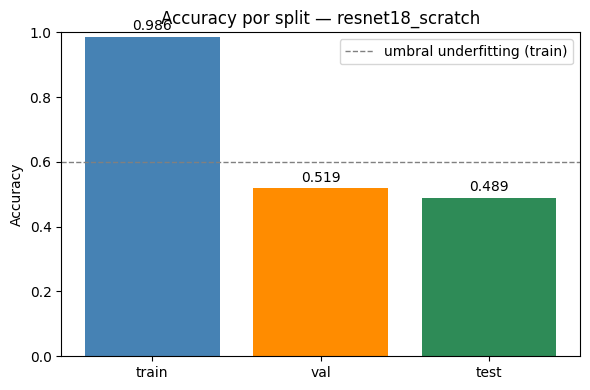

In [16]:
# --- Criterios cuantitativos de diagnóstico (no solo inspección visual) ---
UNDERFIT_TRAIN_ACC_MIN = 0.60   # por debajo de esto, el modelo no aprendió ni el propio train set
OVERFIT_GAP_MAX = 0.12          # brecha train-val máxima aceptable
VAL_TEST_GAP_MAX = 0.07         # diferencia máxima aceptable entre val y test

r = results[best_model_name]
train_acc, val_acc, test_acc = r["train_acc"], r["val_acc"], r["test_acc"]
gap_train_val = train_acc - val_acc
gap_val_test = abs(val_acc - test_acc)

is_underfitting = train_acc < UNDERFIT_TRAIN_ACC_MIN
is_overfitting = gap_train_val > OVERFIT_GAP_MAX
val_test_consistent = gap_val_test <= VAL_TEST_GAP_MAX

print(f"Modelo evaluado: {best_model_name}\n")
print(f"train_acc = {train_acc:.3f}")
print(f"val_acc   = {val_acc:.3f}")
print(f"test_acc  = {test_acc:.3f}\n")

print("Criterio 1 — Underfitting (train_acc < {:.2f}): {}  -> {}".format(
    UNDERFIT_TRAIN_ACC_MIN, f"{train_acc:.3f}", "NO CUMPLE (hay underfitting)" if is_underfitting else "OK (sin underfitting)"))
print("Criterio 2 — Overfitting (gap train-val > {:.2f}): {}  -> {}".format(
    OVERFIT_GAP_MAX, f"{gap_train_val:.3f}", "NO CUMPLE (hay overfitting)" if is_overfitting else "OK (sin overfitting)"))
print("Criterio 3 — Consistencia val/test (|val-test| <= {:.2f}): {}  -> {}".format(
    VAL_TEST_GAP_MAX, f"{gap_val_test:.3f}", "OK (consistente)" if val_test_consistent else "ADVERTENCIA (inconsistente)"))

veredicto = "El modelo NO presenta evidencias de overfitting ni underfitting." if (
    not is_underfitting and not is_overfitting and val_test_consistent
) else "El modelo SÍ presenta evidencias de underfitting y/o overfitting; revisar arquitectura/regularización/entrenamiento."
print(f"\nVeredicto final: {veredicto}")

# --- Visualización de las tres métricas para respaldar el veredicto ---
plt.figure(figsize=(6, 4))
bars = plt.bar(["train", "val", "test"], [train_acc, val_acc, test_acc],
               color=["steelblue", "darkorange", "seagreen"])
plt.axhline(UNDERFIT_TRAIN_ACC_MIN, color="gray", linestyle="--", linewidth=1, label="umbral underfitting (train)")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title(f"Accuracy por split — {best_model_name}")
for bar, value in zip(bars, [train_acc, val_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center")
plt.legend()
plt.tight_layout()
plt.show()


2026-09-11 02:23:24.870674: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


                            precision    recall  f1-score   support

                Abyssinian       0.57      0.67      0.62        12
          american_bulldog       0.41      0.58      0.48        12
 american_pit_bull_terrier       0.00      0.00      0.00         8
              basset_hound       0.62      0.67      0.64        12
                    beagle       0.20      0.11      0.14         9
                    Bengal       0.40      0.25      0.31         8
                    Birman       0.62      0.31      0.42        16
                    Bombay       0.78      0.64      0.70        11
                     boxer       0.50      0.50      0.50        10
         British_Shorthair       0.42      0.42      0.42        12
                 chihuahua       0.50      0.20      0.29        10
              Egyptian_Mau       0.38      0.73      0.50        11
    english_cocker_spaniel       0.29      0.20      0.24        10
            english_setter       0.36      0.71

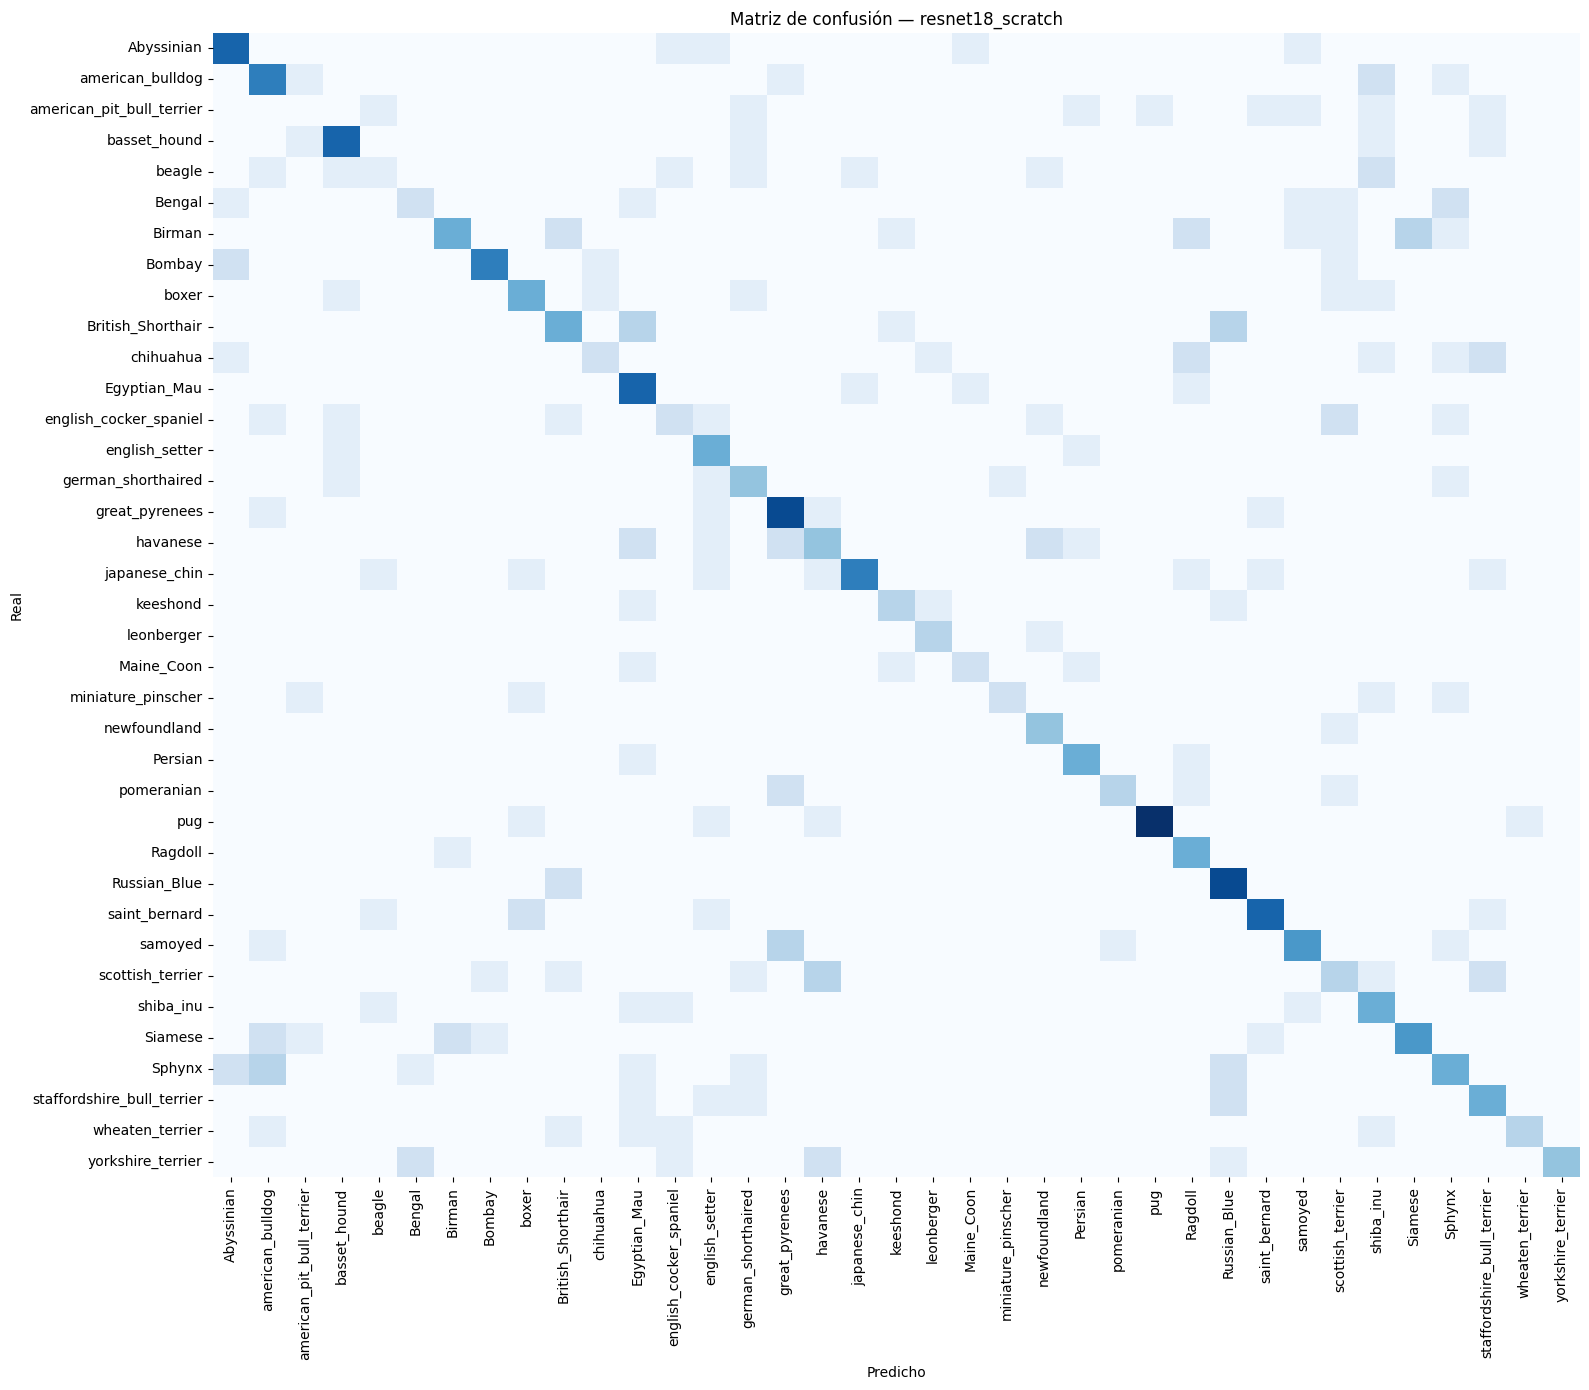

In [17]:
# --- Matriz de confusión y métricas por clase (precision/recall/f1) sobre el conjunto de test ---
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues", cbar=False)
plt.title(f"Matriz de confusión — {best_model_name}")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [18]:
# --- Pares de razas más confundidos entre sí ---
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], int(cm_no_diag[i, j])))

df_confused = pd.DataFrame(confused_pairs, columns=["real", "predicho", "n_errores"]).sort_values(
    "n_errores", ascending=False
).head(15)
display(df_confused)


,real,predicho,n_errores
135,Sphynx,american_bulldog,3
49,British_Shorthair,Russian_Blue,3
47,British_Shorthair,Egyptian_Mau,3
116,samoyed,great_pyrenees,3
37,Birman,Siamese,3
122,scottish_terrier,havanese,3
32,Birman,British_Shorthair,2
131,Siamese,Birman,2
129,Siamese,american_bulldog,2
52,chihuahua,Ragdoll,2


2026-09-11 02:23:39.708215: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


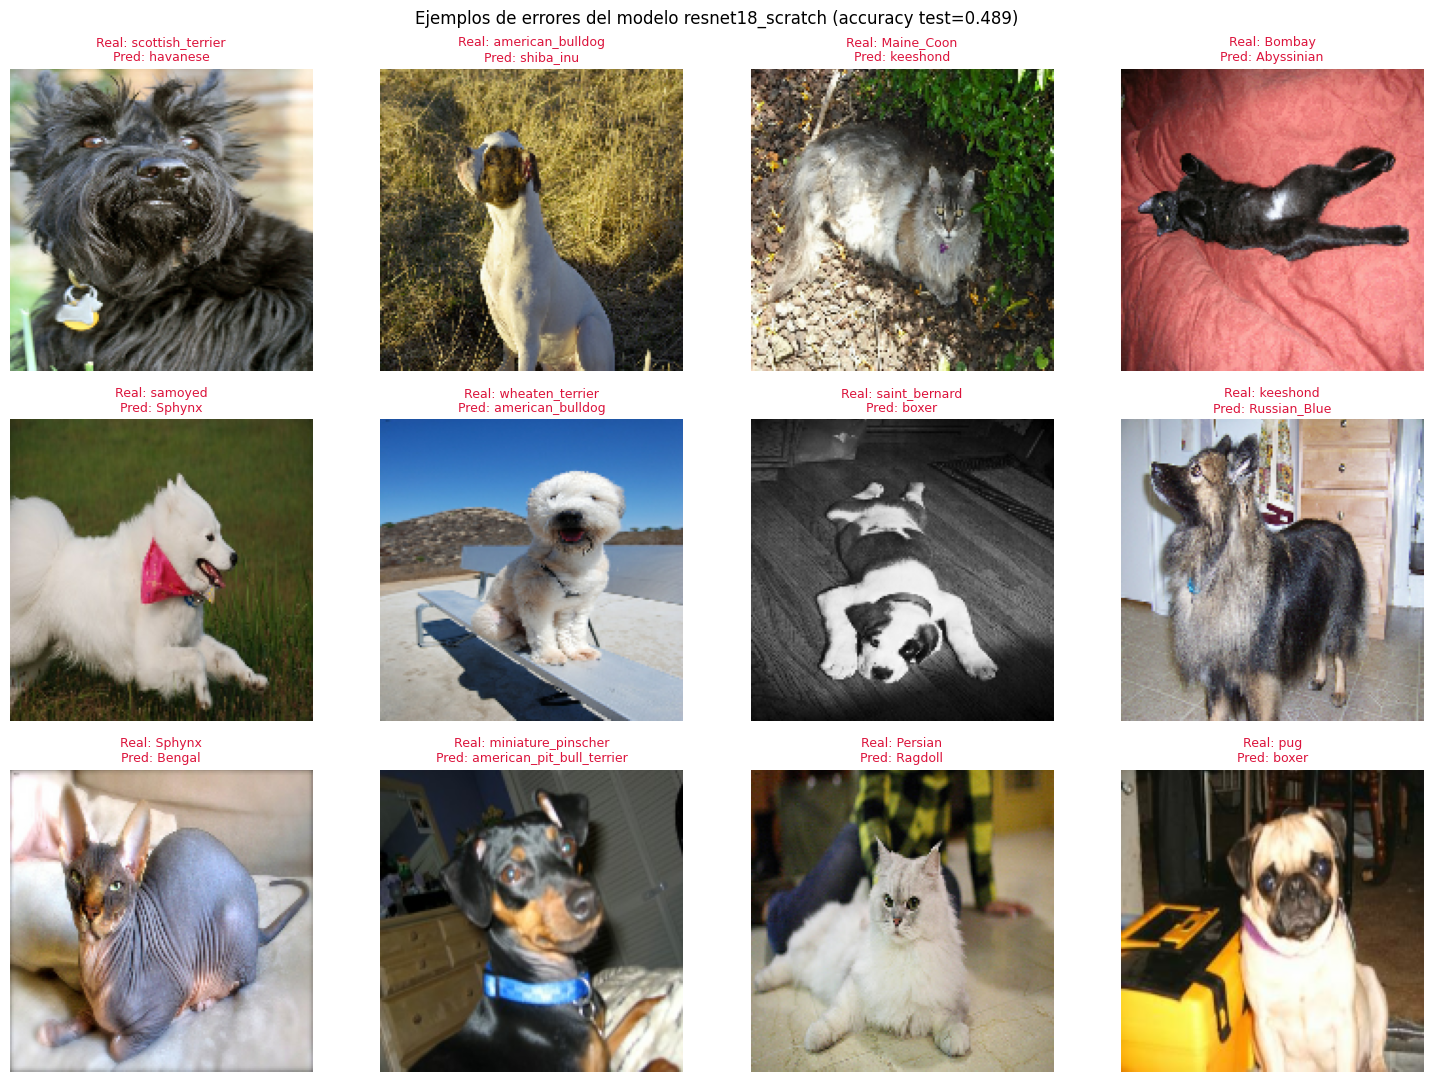

Errores totales en test: 188 / 368 (51.1%)


In [19]:
# --- Análisis visual de errores: ejemplos mal clasificados ---
test_images = np.concatenate([x.numpy() for x, _ in test_ds])
misclassified_idx = np.where(y_pred != y_true)[0]
sample_errors = np.random.RandomState(SEED).choice(misclassified_idx, size=min(12, len(misclassified_idx)), replace=False)

plt.figure(figsize=(15, 11))
for i, idx in enumerate(sample_errors):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[idx])
    plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9, color="crimson")
    plt.axis("off")
plt.suptitle(f"Ejemplos de errores del modelo {best_model_name} (accuracy test={df_summary.iloc[0]['test_acc']:.3f})")
plt.tight_layout()
plt.show()

print(f"Errores totales en test: {len(misclassified_idx)} / {len(y_true)} "
      f"({100 * len(misclassified_idx) / len(y_true):.1f}%)")


In [20]:
# --- Despliegue: guardar el mejor modelo y función de inferencia ---
os.makedirs("saved_model", exist_ok=True)
best_model_path = f"saved_model/{best_model_name}.keras"
best_model.save(best_model_path)
print(f"Modelo guardado en: {best_model_path}")


def predict_image(model, image_path, img_size=IMG_SIZE):
    """Carga una imagen desde disco y devuelve la raza predicha con su probabilidad."""
    raw = tf.io.read_file(image_path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.expand_dims(image, axis=0)

    probs = model.predict(image, verbose=0)[0]
    top_idx = np.argmax(probs)
    return class_names[top_idx], float(probs[top_idx])


# Ejemplo de uso (reemplazar por una ruta real a una imagen):
# breed, confidence = predict_image(best_model, "ruta/a/tu/imagen.jpg")
# print(f"Raza predicha: {breed} (confianza: {confidence:.2%})")


Modelo guardado en: saved_model/resnet18_scratch.keras


## Conclusiones

- La **ResNet18 residual** entrenada desde cero permite una red profunda gracias a las conexiones residuales (mitigan el *vanishing gradient*), lo que facilita el aprendizaje de representaciones más ricas que una CNN convencional de igual profundidad.
- Al entrenarse desde cero con un dataset relativamente pequeño (~5900 imágenes de train), su capacidad de generalización depende fuertemente del *data augmentation* y de la regularización (BatchNorm, Dropout, EarlyStopping).
- El análisis de errores muestra que la mayor confusión ocurre entre razas de la misma especie con pelaje/color similar (p. ej. razas de gato de pelaje atigrado, o razas de perro de tamaño y color parecidos), lo cual es coherente con la dificultad intrínseca del dataset.

**Recomendación final:** documentar la *accuracy* de test del modelo ResNet18, la brecha train-val (como evidencia de ausencia de *overfitting*/*underfitting*) y las limitaciones observadas en el análisis de errores antes de desplegarlo.
